# Lab 4.2: Patch Extraction & Normalization

**Date:** 5 March 2026  
**Instructor:** Samy (online)

## ⏱️ Time Allocation (2h 20min)
- **Part 1 (15 min):** Loading aligned data from Lab 4.1
- **Part 2 (45 min):** Extracting labeled patches
- **Part 3 (30 min):** Data normalization techniques
- **Part 4 (30 min):** Analyzing class distributions
- **Part 5 (20 min):** Combining and saving datasets

## 🎯 Learning Objectives

### Core (Essential - Everyone Should Complete)
- ✅ Load aligned S2 and CORINE data from Lab 4.1
- ✅ Extract fixed-size patches with CORINE labels
- ✅ Apply normalization techniques to satellite imagery
- ✅ Analyze class distributions in training data
- ✅ Save ML-ready training datasets

### Optional (For Early Finishers)
- 🔵 Customize patch size and stride
- 🔵 Implement class balancing strategies
- 🔵 Combine multiple tiles into unified dataset

## 📋 Prerequisites
You must complete **Lab 4.1** first to create the aligned data files:
- `*_stacked.tif` - Stacked S2 bands
- `corine_aligned_*.tif` - Aligned CORINE labels

---

## Section 1: Environment Setup

### Import Required Libraries

In [1]:
import os
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import rasterio

# Set matplotlib config directory to avoid permission issues
os.environ['MPLCONFIGDIR'] = f"/tmp/matplotlib_{os.environ.get('USER', 'user')}"

print("✓ Libraries imported successfully")
print(f"  rasterio version: {rasterio.__version__}")
print(f"  NumPy version: {np.__version__}")

✓ Libraries imported successfully
  rasterio version: 1.5.0
  NumPy version: 1.26.4


### Define CORINE Class Mapping

In [2]:
# CORINE class descriptions (simplified codes 1-44 used in raster)
CORINE_CLASSES = {
    # Artificial surfaces (1-11)
    1: "Continuous urban fabric",
    2: "Discontinuous urban fabric",
    3: "Industrial or commercial units",
    4: "Road and rail networks",
    5: "Port areas",
    6: "Airports",
    7: "Mineral extraction sites",
    8: "Dump sites",
    9: "Construction sites",
    10: "Green urban areas",
    11: "Sport and leisure facilities",
    
    # Agricultural areas (12-22)
    12: "Non-irrigated arable land",
    13: "Permanently irrigated land",
    14: "Rice fields",
    15: "Vineyards",
    16: "Fruit trees and berry plantations",
    17: "Olive groves",
    18: "Pastures",
    19: "Annual crops with permanent crops",
    20: "Complex cultivation patterns",
    21: "Agriculture with natural vegetation",
    22: "Agro-forestry areas",
    
    # Forest and semi-natural areas (23-34)
    23: "Broad-leaved forest",
    24: "Coniferous forest",
    25: "Mixed forest",
    26: "Natural grasslands",
    27: "Moors and heathland",
    28: "Sclerophyllous vegetation",
    29: "Transitional woodland-shrub",
    30: "Beaches, dunes, sands",
    31: "Bare rocks",
    32: "Sparsely vegetated areas",
    33: "Burnt areas",
    34: "Glaciers and perpetual snow",
    
    # Wetlands (35-39)
    35: "Inland marshes",
    36: "Peat bogs",
    37: "Salt marshes",
    38: "Salines",
    39: "Intertidal flats",
    
    # Water bodies (40-44)
    40: "Water courses",
    41: "Water bodies",
    42: "Coastal lagoons",
    43: "Estuaries",
    44: "Sea and ocean",
    
    48: "No data"
}

# Color mapping for visualization
CORINE_COLORS = {
    1: '#E6004D', 2: '#FF0000', 3: '#CC4DF2', 4: '#CC0000', 5: '#E6CCCC',
    6: '#E6CCE6', 7: '#A600CC', 8: '#A64DCC', 9: '#FF4DFF', 10: '#FFA6FF',
    11: '#FFE6FF', 12: '#FFFFA8', 13: '#FFFF00', 14: '#E6E600', 15: '#E68000',
    16: '#F2A64D', 17: '#E6A600', 18: '#E6E64D', 19: '#FFE6A6', 20: '#FFE64D',
    21: '#E6CC4D', 22: '#F2CCA6', 23: '#80FF00', 24: '#00A600', 25: '#4DFF00',
    26: '#CCF24D', 27: '#A6FF80', 28: '#A6E64D', 29: '#A6F200', 30: '#E6E6E6',
    31: '#CCCCCC', 32: '#CCFFCC', 33: '#000000', 34: '#A6E6CC', 35: '#A6A6FF',
    36: '#4D4DFF', 37: '#CCCCFF', 38: '#E6E6FF', 39: '#A6A6E6', 40: '#00CCF2',
    41: '#80F2E6', 42: '#00FFA6', 43: '#A6FFE6', 44: '#E6F2FF'
}

print(f"✓ Defined {len(CORINE_CLASSES)} CORINE land cover classes")

✓ Defined 45 CORINE land cover classes


## Section 2: Configure Parameters

### 🔧 Set Your Paths and Options

**Edit the cell below to configure:**
1. Path to aligned data from Lab 4.1
2. Patch extraction parameters
3. Normalization settings
4. Output directory for training data

In [3]:
# ============================================================
# CONFIGURATION - Edit these values!
# ============================================================

# Get username for default paths
USER = os.environ.get('USER', 'user')

# --- Path Configuration ---
# Directory containing aligned data from Lab 4.1
ALIGNED_DATA_DIR = f"/p/scratch/training2600/{USER}/data/aligned_data"

# Output directory for training patches
OUTPUT_DIR = f"/p/scratch/training2600/{USER}/training_data"

# --- Tile Selection ---
# Options:
#   'all'  - Process all aligned tile pairs found
#   'list' - Process only tiles listed in TILE_LIST below
TILE_SELECTION = 'all'

# If TILE_SELECTION = 'list', specify which tiles to process:
TILE_LIST = [
    # Add your specific tile names here (without _stacked.tif suffix)
]

# --- Patch Extraction Parameters ---
PATCH_SIZE = 3       # Size in pixels (3 = 30m x 30m at 10m resolution)
STRIDE = None        # Stride for extraction (None = same as PATCH_SIZE, no overlap)
MAX_PATCHES = 50000  # Maximum patches per tile

# --- Normalization Settings ---
# Options: 'minmax', 'zscore', 'percentile', 'none'
NORMALIZATION = 'percentile'

# For percentile normalization: clip to these percentiles
PERCENTILE_LOW = 2
PERCENTILE_HIGH = 98

# --- Processing Options ---
SKIP_EXISTING = True  # Skip tiles that already have output files

# ============================================================
print("Configuration:")
print(f"  Aligned Data Directory: {ALIGNED_DATA_DIR}")
print(f"  Output Directory: {OUTPUT_DIR}")
print(f"  Tile Selection: {TILE_SELECTION}")
print(f"  Patch Size: {PATCH_SIZE}x{PATCH_SIZE} ({PATCH_SIZE * 10}m x {PATCH_SIZE * 10}m)")
print(f"  Max Patches per Tile: {MAX_PATCHES:,}")
print(f"  Normalization: {NORMALIZATION}")

Configuration:
  Aligned Data Directory: /p/scratch/training2600/kristinsson3/data/aligned_data
  Output Directory: /p/scratch/training2600/kristinsson3/training_data
  Tile Selection: all
  Patch Size: 3x3 (30m x 30m)
  Max Patches per Tile: 50,000
  Normalization: percentile


### Discover Available Aligned Data

In [4]:
def find_aligned_pairs(data_dir, selection='all', tile_list=None):
    """
    Find pairs of stacked S2 and aligned CORINE files.
    
    Returns:
    --------
    list : List of dicts with 's2_path', 'corine_path', 'tile_name'
    """
    data_path = Path(data_dir)
    
    if not data_path.exists():
        print(f"❌ Data directory not found: {data_dir}")
        print("\n💡 Have you completed Lab 4.1 to create aligned data?")
        return []
    
    # Find all stacked S2 files
    s2_files = sorted(data_path.glob("*_stacked.tif"))
    
    pairs = []
    for s2_path in s2_files:
        # Extract tile name
        tile_name = s2_path.stem.replace('_stacked', '')
        
        # Check if we should include this tile
        if selection == 'list' and tile_list:
            if tile_name not in tile_list:
                continue
        
        # Find matching CORINE file
        corine_path = data_path / f"corine_aligned_{tile_name}.tif"
        
        if corine_path.exists():
            pairs.append({
                's2_path': s2_path,
                'corine_path': corine_path,
                'tile_name': tile_name
            })
        else:
            print(f"⚠ Missing CORINE for: {tile_name}")
    
    return pairs

# Find aligned pairs
aligned_pairs = find_aligned_pairs(ALIGNED_DATA_DIR, TILE_SELECTION, TILE_LIST)

print(f"\n📂 Found {len(aligned_pairs)} aligned tile pair(s):")
for i, pair in enumerate(aligned_pairs, 1):
    print(f"  {i}. {pair['tile_name'][:60]}...")

if len(aligned_pairs) == 0:
    print("\n⚠ No aligned data found!")
    print("  Please complete Lab 4.1 first to align CORINE with S2 tiles.")


📂 Found 4 aligned tile pair(s):
  1. S2A_MSIL2A_20180526T100031_N0500_R122_T35WMP_20230823T013228...
  2. S2B_MSIL2A_20180315T101019_N0500_R022_T35WMP_20230908T210616...
  3. S2B_MSIL2A_20180812T101019_N0500_R022_T35WMP_20230815T141353...
  4. S2B_MSIL2A_20181028T100119_N0500_R122_T35WMP_20230729T125703...


## Section 3: Normalization Functions

### Why Normalize Satellite Imagery?

Sentinel-2 imagery has 12-bit radiometric resolution (values 0-4095+), but:
- Different bands have different value ranges
- Atmospheric conditions affect values
- ML models work better with normalized inputs

### Common Normalization Techniques

In [5]:
def normalize_minmax(data, min_val=0, max_val=10000):
    """
    Min-max normalization to [0, 1] range.
    
    Parameters:
    -----------
    data : np.ndarray
        Input data (any shape)
    min_val : float
        Minimum value for scaling (default 0 for S2)
    max_val : float
        Maximum value for scaling (default 10000 for S2 L2A)
    
    Returns:
    --------
    np.ndarray : Normalized data in [0, 1]
    """
    data = data.astype(np.float32)
    normalized = (data - min_val) / (max_val - min_val + 1e-6)
    return np.clip(normalized, 0, 1)


def normalize_zscore(data, mean=None, std=None):
    """
    Z-score normalization (standardization).
    
    Parameters:
    -----------
    data : np.ndarray
        Input data
    mean : float or None
        Mean value (computed if None)
    std : float or None
        Std value (computed if None)
    
    Returns:
    --------
    tuple : (normalized_data, mean, std)
    """
    data = data.astype(np.float32)
    if mean is None:
        mean = np.mean(data)
    if std is None:
        std = np.std(data)
    normalized = (data - mean) / (std + 1e-6)
    return normalized, mean, std


def normalize_percentile(data, low_pct=2, high_pct=98):
    """
    Percentile-based normalization (robust to outliers).
    
    Parameters:
    -----------
    data : np.ndarray
        Input data
    low_pct : float
        Low percentile for clipping
    high_pct : float
        High percentile for clipping
    
    Returns:
    --------
    tuple : (normalized_data, low_val, high_val)
    """
    data = data.astype(np.float32)
    low_val = np.percentile(data, low_pct)
    high_val = np.percentile(data, high_pct)
    normalized = (data - low_val) / (high_val - low_val + 1e-6)
    normalized = np.clip(normalized, 0, 1)
    return normalized, low_val, high_val


def normalize_data(data, method='percentile', **kwargs):
    """
    Normalize data using specified method.
    
    Parameters:
    -----------
    data : np.ndarray
        Input data
    method : str
        'minmax', 'zscore', 'percentile', or 'none'
    **kwargs : dict
        Additional arguments for the normalization method
    
    Returns:
    --------
    tuple : (normalized_data, norm_params)
    """
    if method == 'minmax':
        normalized = normalize_minmax(data, **kwargs)
        params = {'method': 'minmax', **kwargs}
    elif method == 'zscore':
        normalized, mean, std = normalize_zscore(data, **kwargs)
        params = {'method': 'zscore', 'mean': float(mean), 'std': float(std)}
    elif method == 'percentile':
        low_pct = kwargs.get('low_pct', 2)
        high_pct = kwargs.get('high_pct', 98)
        normalized, low_val, high_val = normalize_percentile(data, low_pct, high_pct)
        params = {'method': 'percentile', 'low_pct': low_pct, 'high_pct': high_pct,
                  'low_val': float(low_val), 'high_val': float(high_val)}
    else:  # 'none'
        normalized = data.astype(np.float32)
        params = {'method': 'none'}
    
    return normalized, params


print("✓ Normalization functions defined")
print("\nAvailable methods:")
print("  - minmax: Scale to [0, 1] using fixed min/max")
print("  - zscore: Standardize to mean=0, std=1")
print("  - percentile: Robust scaling using percentiles")
print("  - none: Keep original values (as float32)")

✓ Normalization functions defined

Available methods:
  - minmax: Scale to [0, 1] using fixed min/max
  - zscore: Standardize to mean=0, std=1
  - percentile: Robust scaling using percentiles
  - none: Keep original values (as float32)


## Section 4: Patch Extraction

### Define Extraction Function

In [6]:
def extract_patches(s2_path, corine_path, patch_size=3, stride=None, max_patches=50000,
                    normalization='percentile', norm_kwargs=None):
    """
    Extract training patches from aligned S2 imagery with CORINE labels.
    
    Parameters:
    -----------
    s2_path : Path
        Path to stacked S2 GeoTIFF
    corine_path : Path
        Path to aligned CORINE GeoTIFF
    patch_size : int
        Patch size in pixels
    stride : int
        Stride for extraction (None = patch_size)
    max_patches : int
        Maximum patches to extract
    normalization : str
        Normalization method
    norm_kwargs : dict
        Additional arguments for normalization
    
    Returns:
    --------
    tuple : (patches, labels, metadata) or (None, None, None)
    """
    if norm_kwargs is None:
        norm_kwargs = {}
    
    try:
        # Open datasets using rasterio
        with rasterio.open(s2_path) as s2_src, rasterio.open(corine_path) as corine_src:
            n_bands = s2_src.count
            height = s2_src.height
            width = s2_src.width
            
            if stride is None:
                stride = patch_size
            
            print(f"    Image size: {width} x {height} pixels")
            print(f"    Bands: {n_bands}")
            print(f"    Patch size: {patch_size}, Stride: {stride}")
            
            # Read all data into memory (for efficiency)
            # Shape: (bands, height, width)
            s2_data = s2_src.read()
            corine_data = corine_src.read(1)
        
        # Apply normalization to entire image first (for consistent statistics)
        print(f"    Applying {normalization} normalization...")
        s2_normalized, norm_params = normalize_data(s2_data, normalization, **norm_kwargs)
        
        # Extract patches
        patches, labels = [], []
        
        for y in range(0, height - patch_size + 1, stride):
            for x in range(0, width - patch_size + 1, stride):
                # Extract patch (bands, h, w) -> (h, w, bands)
                patch = s2_normalized[:, y:y+patch_size, x:x+patch_size]
                patch = np.transpose(patch, (1, 2, 0))  # (H, W, C)
                
                # Get center pixel label
                center_y = y + patch_size // 2
                center_x = x + patch_size // 2
                label = corine_data[center_y, center_x]
                
                # Skip invalid labels (must be 1-44)
                if label < 1 or label > 44:
                    continue
                
                # Skip patches with missing S2 data (check original before normalization)
                original_patch = s2_data[:, y:y+patch_size, x:x+patch_size]
                if np.any(original_patch == 0):
                    continue
                
                patches.append(patch)
                labels.append(label)
                
                if len(patches) >= max_patches:
                    break
            
            if len(patches) >= max_patches:
                break
            
            # Progress update
            if y % 2000 == 0 and y > 0:
                print(f"    Progress: {len(patches):,} patches extracted...")
        
        if len(patches) == 0:
            return None, None, None
        
        # Convert to arrays
        patches = np.array(patches, dtype=np.float32)
        labels = np.array(labels, dtype=np.uint8)
        
        # Create metadata
        unique_labels, counts = np.unique(labels, return_counts=True)
        metadata = {
            's2_file': Path(s2_path).name,
            'corine_file': Path(corine_path).name,
            'patch_size': patch_size,
            'stride': stride,
            'n_patches': len(patches),
            'n_bands': patches.shape[3],
            'n_classes': len(unique_labels),
            'label_distribution': {int(k): int(v) for k, v in zip(unique_labels, counts)},
            'extraction_date': datetime.now().isoformat(),
            'patch_shape': list(patches.shape),
            'bands': ['B02', 'B03', 'B04', 'B08'],
            'normalization': norm_params
        }
        
        return patches, labels, metadata
        
    except Exception as e:
        print(f"  ❌ Patch extraction failed: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None


print("✓ Patch extraction function defined")

✓ Patch extraction function defined


### Process Tile Function

In [7]:
def process_tile_extraction(pair, output_dir, patch_size, stride, max_patches,
                            normalization, norm_kwargs, skip_existing=True):
    """
    Extract patches from a single aligned tile pair.
    
    Returns:
    --------
    dict : Processing results
    """
    tile_name = pair['tile_name']
    s2_path = pair['s2_path']
    corine_path = pair['corine_path']
    
    result = {
        'tile': tile_name,
        'status': 'unknown',
        'n_patches': 0,
        'n_classes': 0,
        'output_file': None,
        'metadata': None
    }
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Output paths
    output_npz = output_dir / f"patches_{tile_name}_data.npz"
    metadata_file = output_dir / f"patches_{tile_name}_metadata.json"
    
    # Check for existing output
    if skip_existing and output_npz.exists():
        print(f"  ⏭ Skipping (output exists)")
        if metadata_file.exists():
            with open(metadata_file) as f:
                result['metadata'] = json.load(f)
                result['n_patches'] = result['metadata'].get('n_patches', 0)
                result['n_classes'] = result['metadata'].get('n_classes', 0)
        result['status'] = 'skipped'
        result['output_file'] = str(output_npz)
        return result
    
    # Extract patches
    print(f"  ✂️ Extracting patches...")
    patches, labels, metadata = extract_patches(
        s2_path, corine_path, 
        patch_size=patch_size, 
        stride=stride, 
        max_patches=max_patches,
        normalization=normalization,
        norm_kwargs=norm_kwargs
    )
    
    if patches is None:
        result['status'] = 'no_patches'
        return result
    
    # Save results
    print(f"  💾 Saving {len(patches):,} patches...")
    np.savez_compressed(output_npz, patches=patches, labels=labels)
    
    with open(metadata_file, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    result['status'] = 'success'
    result['n_patches'] = len(patches)
    result['n_classes'] = metadata['n_classes']
    result['output_file'] = str(output_npz)
    result['metadata'] = metadata
    
    return result


print("✓ Tile processing function defined")

✓ Tile processing function defined


### Main Processing Loop

In [8]:
# ============================================================
# MAIN PROCESSING LOOP
# ============================================================

print("="*70)
print("EXTRACTING TRAINING PATCHES")
print("="*70)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Tiles to process: {len(aligned_pairs)}")
print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE} pixels")
print(f"Max patches per tile: {MAX_PATCHES:,}")
print(f"Normalization: {NORMALIZATION}")
print()

# Prepare normalization kwargs
norm_kwargs = {}
if NORMALIZATION == 'percentile':
    norm_kwargs = {'low_pct': PERCENTILE_LOW, 'high_pct': PERCENTILE_HIGH}

# Store results
all_results = []

# Process each tile
for i, pair in enumerate(aligned_pairs, 1):
    print(f"\n[{i}/{len(aligned_pairs)}] Processing: {pair['tile_name'][:50]}...")
    
    result = process_tile_extraction(
        pair=pair,
        output_dir=OUTPUT_DIR,
        patch_size=PATCH_SIZE,
        stride=STRIDE,
        max_patches=MAX_PATCHES,
        normalization=NORMALIZATION,
        norm_kwargs=norm_kwargs,
        skip_existing=SKIP_EXISTING
    )
    
    all_results.append(result)
    
    if result['status'] == 'success':
        print(f"  ✅ Success: {result['n_patches']:,} patches, {result['n_classes']} classes")
    elif result['status'] == 'skipped':
        print(f"  ⏭ Skipped (already processed): {result['n_patches']:,} patches")
    else:
        print(f"  ❌ Status: {result['status']}")

# Summary
print("\n" + "="*70)
print("EXTRACTION SUMMARY")
print("="*70)
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

successful = [r for r in all_results if r['status'] == 'success']
skipped = [r for r in all_results if r['status'] == 'skipped']
failed = [r for r in all_results if r['status'] not in ['success', 'skipped']]

print(f"\nResults:")
print(f"  ✅ Successful: {len(successful)}")
print(f"  ⏭ Skipped: {len(skipped)}")
print(f"  ❌ Failed: {len(failed)}")

total_patches = sum(r['n_patches'] for r in all_results if r['n_patches'] > 0)
print(f"\n  Total patches extracted: {total_patches:,}")
print(f"  Output directory: {OUTPUT_DIR}")

EXTRACTING TRAINING PATCHES
Start time: 2026-03-05 11:07:02
Tiles to process: 4
Patch size: 3x3 pixels
Max patches per tile: 50,000
Normalization: percentile


[1/4] Processing: S2A_MSIL2A_20180526T100031_N0500_R122_T35WMP_20230...
  ✂️ Extracting patches...
    Image size: 10980 x 10980 pixels
    Bands: 4
    Patch size: 3, Stride: 3
    Applying percentile normalization...
  💾 Saving 50,000 patches...
  ✅ Success: 50,000 patches, 10 classes

[2/4] Processing: S2B_MSIL2A_20180315T101019_N0500_R022_T35WMP_20230...
  ✂️ Extracting patches...
    Image size: 10980 x 10980 pixels
    Bands: 4
    Patch size: 3, Stride: 3
    Applying percentile normalization...
  💾 Saving 50,000 patches...
  ✅ Success: 50,000 patches, 10 classes

[3/4] Processing: S2B_MSIL2A_20180812T101019_N0500_R022_T35WMP_20230...
  ✂️ Extracting patches...
    Image size: 10980 x 10980 pixels
    Bands: 4
    Patch size: 3, Stride: 3
    Applying percentile normalization...
  💾 Saving 50,000 patches...
  ✅ Success: 5

In [9]:
%matplotlib inline

## Section 5: Analyze and Visualize Results

### View Processing Results

In [10]:
# Display detailed results
print("Detailed Results per Tile:")
print("-" * 80)

for result in all_results:
    status_icon = "✅" if result['status'] == 'success' else "⏭" if result['status'] == 'skipped' else "❌"
    print(f"{status_icon} {result['tile'][:50]}...")
    print(f"    Status: {result['status']}")
    if result['n_patches'] > 0:
        print(f"    Patches: {result['n_patches']:,}")
        print(f"    Classes: {result['n_classes']}")
        if result['output_file']:
            size_mb = Path(result['output_file']).stat().st_size / (1024 * 1024)
            print(f"    File: {Path(result['output_file']).name} ({size_mb:.1f} MB)")
        if result['metadata'] and 'normalization' in result['metadata']:
            norm = result['metadata']['normalization']
            print(f"    Normalization: {norm['method']}")
    print()

Detailed Results per Tile:
--------------------------------------------------------------------------------
✅ S2A_MSIL2A_20180526T100031_N0500_R122_T35WMP_20230...
    Status: success
    Patches: 50,000
    Classes: 10
    File: patches_S2A_MSIL2A_20180526T100031_N0500_R122_T35WMP_20230823T013228_data.npz (3.2 MB)
    Normalization: percentile

✅ S2B_MSIL2A_20180315T101019_N0500_R022_T35WMP_20230...
    Status: success
    Patches: 50,000
    Classes: 10
    File: patches_S2B_MSIL2A_20180315T101019_N0500_R022_T35WMP_20230908T210616_data.npz (4.4 MB)
    Normalization: percentile

✅ S2B_MSIL2A_20180812T101019_N0500_R022_T35WMP_20230...
    Status: success
    Patches: 50,000
    Classes: 10
    File: patches_S2B_MSIL2A_20180812T101019_N0500_R022_T35WMP_20230815T141353_data.npz (3.5 MB)
    Normalization: percentile

✅ S2B_MSIL2A_20181028T100119_N0500_R122_T35WMP_20230...
    Status: success
    Patches: 50,000
    Classes: 10
    File: patches_S2B_MSIL2A_20181028T100119_N0500_R122_T35W

### Visualize Sample Patches

In [11]:
def visualize_patches(patches, labels, n_samples=12, title="Sample Patches"):
    """
    Visualize sample patches with their labels.
    """
    # Get diverse samples (one or two per class)
    unique_labels = np.unique(labels)
    
    sample_indices = []
    for label in unique_labels:
        indices = np.where(labels == label)[0]
        n_from_class = min(2, len(indices))
        sample_indices.extend(np.random.choice(indices, n_from_class, replace=False))
        if len(sample_indices) >= n_samples:
            break
    
    sample_indices = sample_indices[:n_samples]
    
    # Create figure
    n_cols = 4
    n_rows = (len(sample_indices) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes
    
    for i, idx in enumerate(sample_indices):
        patch = patches[idx]
        label = labels[idx]
        
        # Create RGB composite (already normalized, just use R, G, B)
        # Bands are B02, B03, B04, B08 -> RGB is B04, B03, B02 = indices 2, 1, 0
        rgb = patch[:, :, [2, 1, 0]]
        rgb = np.clip(rgb, 0, 1)  # Ensure in [0, 1]
        
        # Upscale for visibility
        rgb_upscaled = np.repeat(np.repeat(rgb, 20, axis=0), 20, axis=1)
        
        axes[i].imshow(rgb_upscaled)
        class_name = CORINE_CLASSES.get(label, "Unknown")[:25]
        axes[i].set_title(f"Class {label}: {class_name}", fontsize=10)
        axes[i].axis('off')
    
    # Hide unused axes
    for i in range(len(sample_indices), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    output_dir = Path(os.getenv('PROJECT_training2600')) / os.getenv('USER') / 'results'
    output_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_dir / "patches_viz.png")
    print("figure saved!")


# Load and visualize first successful result
successful_results = [r for r in all_results if r['status'] in ['success', 'skipped'] and r['output_file']]

if successful_results:
    result = successful_results[0]
    data = np.load(result['output_file'])
    patches = data['patches']
    labels = data['labels']
    
    print(f"Loaded {len(patches):,} patches from: {Path(result['output_file']).name}")
    print(f"Patch value range: [{patches.min():.3f}, {patches.max():.3f}]")
    visualize_patches(patches, labels, n_samples=12, title=f"Sample Patches from {result['tile'][:40]}...")
else:
    print("No successful results to visualize.")

Loaded 50,000 patches from: patches_S2A_MSIL2A_20180526T100031_N0500_R122_T35WMP_20230823T013228_data.npz
Patch value range: [0.000, 1.000]
figure saved!


### Class Distribution Analysis

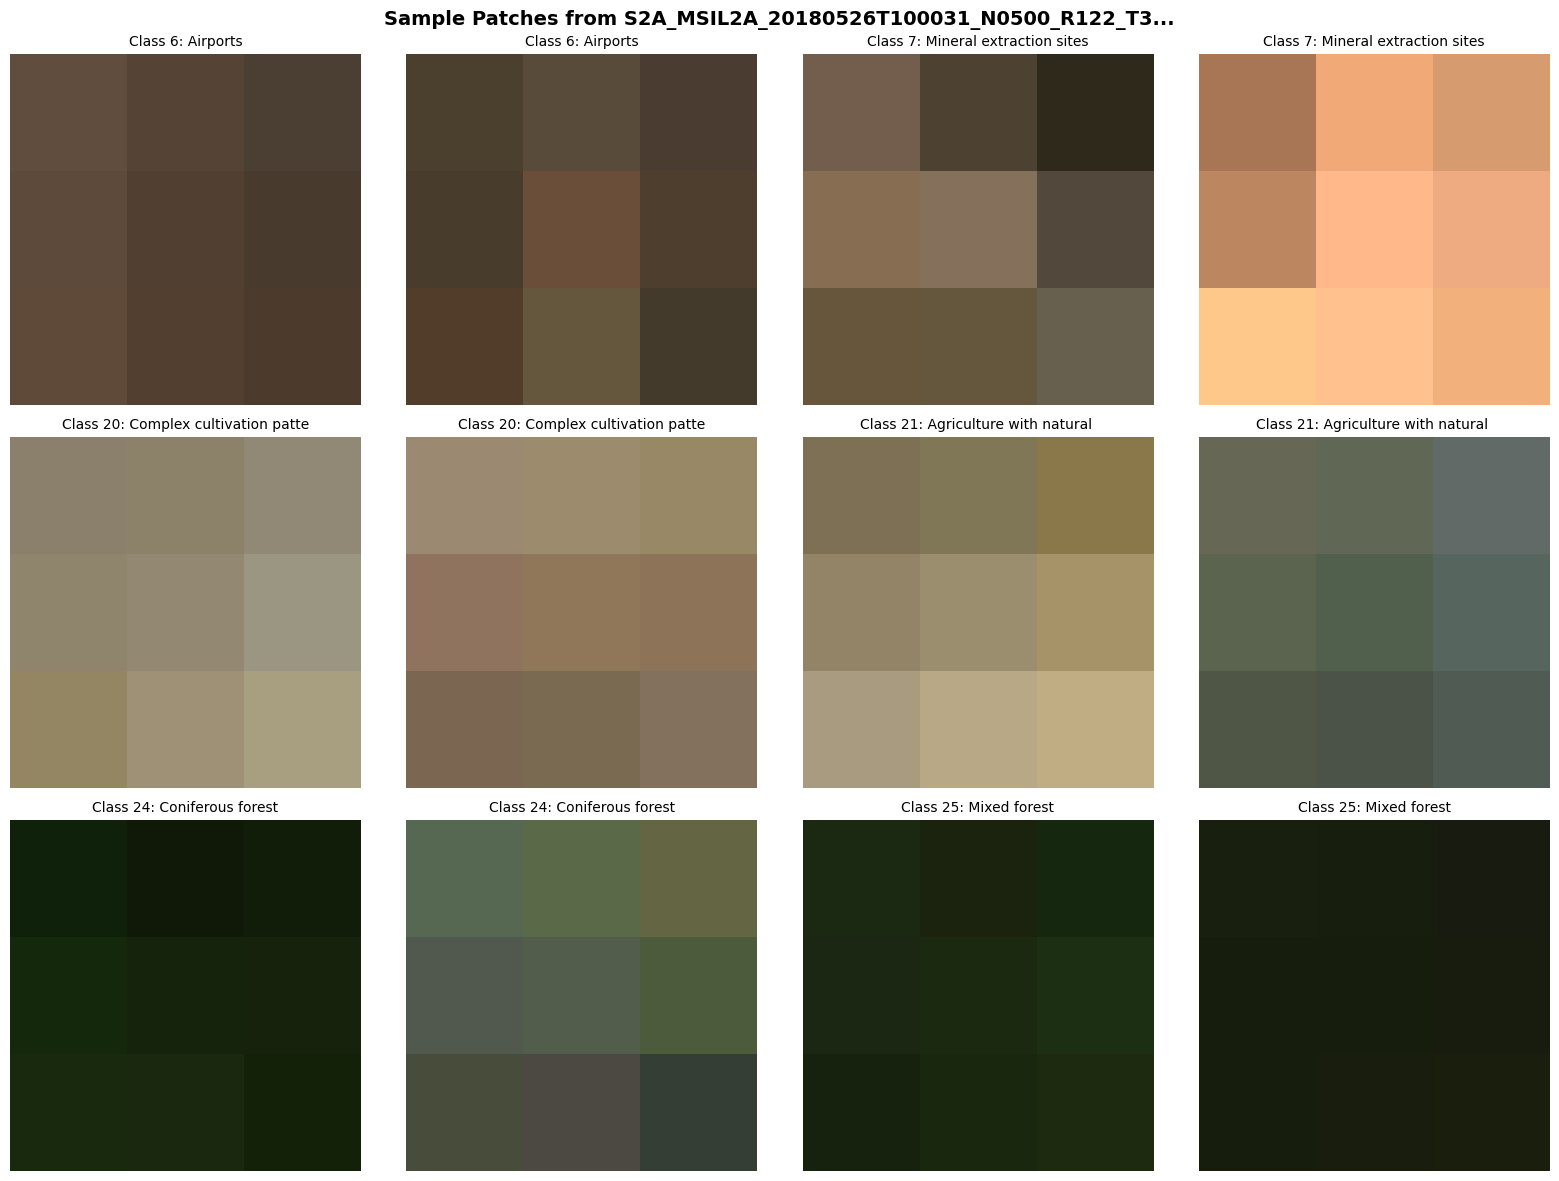

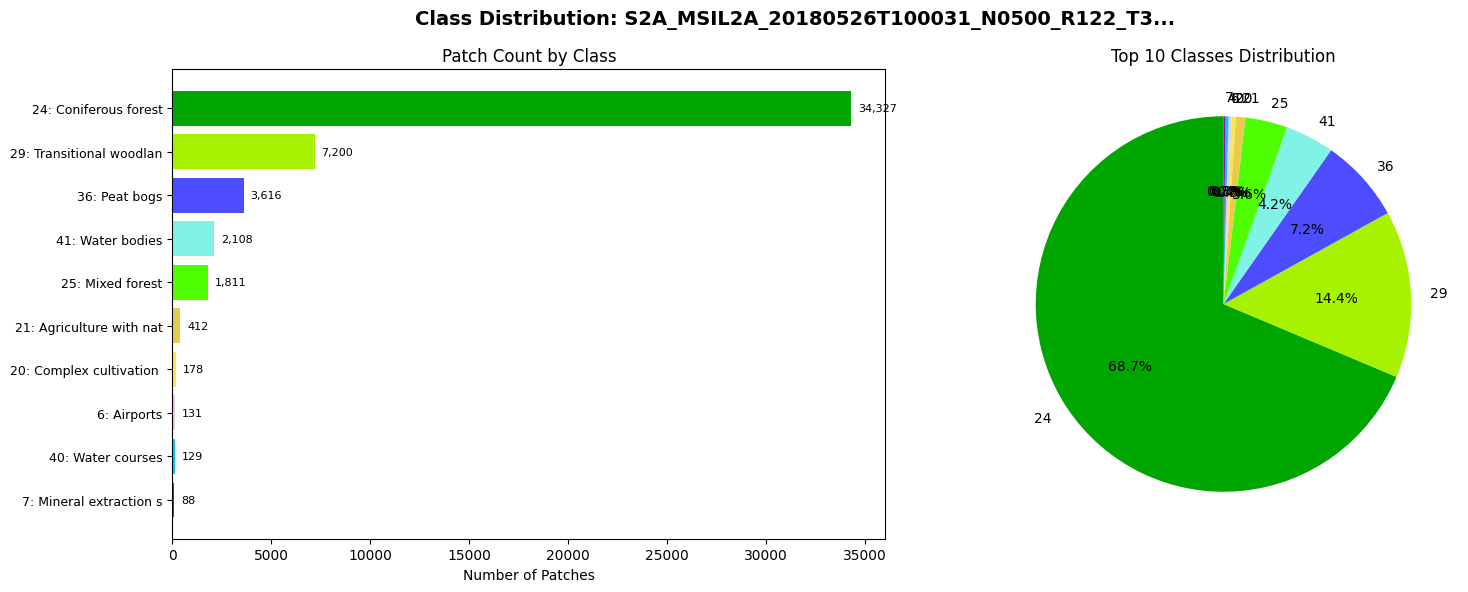


Statistics:
  Total patches: 50,000
  Unique classes: 10
  Most common: Class 24 (Coniferous forest) - 34,327 (68.7%)
  Least common: Class 7 (Mineral extraction sites) - 88 (0.2%)
  Class imbalance ratio: 390.1:1


In [12]:
def plot_class_distribution(labels, title="Class Distribution"):
    """
    Plot the distribution of CORINE classes.
    """
    unique, counts = np.unique(labels, return_counts=True)
    
    # Sort by count
    sort_idx = np.argsort(counts)[::-1]
    unique = unique[sort_idx]
    counts = counts[sort_idx]
    
    # Get class names and colors
    class_names = [f"{c}: {CORINE_CLASSES.get(c, 'Unknown')[:20]}" for c in unique]
    colors = [CORINE_COLORS.get(c, '#888888') for c in unique]
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar chart
    bars = ax1.barh(range(len(unique)), counts, color=colors)
    ax1.set_yticks(range(len(unique)))
    ax1.set_yticklabels(class_names, fontsize=9)
    ax1.set_xlabel('Number of Patches')
    ax1.set_title('Patch Count by Class')
    ax1.invert_yaxis()
    
    # Add count labels
    for i, (count, bar) in enumerate(zip(counts, bars)):
        ax1.text(count + max(counts)*0.01, i, f'{count:,}', va='center', fontsize=8)
    
    # Pie chart (top 10)
    top_n = min(10, len(unique))
    other_count = counts[top_n:].sum() if len(counts) > top_n else 0
    
    pie_counts = list(counts[:top_n])
    pie_labels = [f"{c}" for c in unique[:top_n]]
    pie_colors = colors[:top_n]
    
    if other_count > 0:
        pie_counts.append(other_count)
        pie_labels.append('Other')
        pie_colors.append('#888888')
    
    ax2.pie(pie_counts, labels=pie_labels, colors=pie_colors, 
            autopct='%1.1f%%', startangle=90)
    ax2.set_title('Top 10 Classes Distribution')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nStatistics:")
    print(f"  Total patches: {len(labels):,}")
    print(f"  Unique classes: {len(unique)}")
    print(f"  Most common: Class {unique[0]} ({CORINE_CLASSES.get(unique[0], 'Unknown')}) - {counts[0]:,} ({counts[0]/len(labels)*100:.1f}%)")
    print(f"  Least common: Class {unique[-1]} ({CORINE_CLASSES.get(unique[-1], 'Unknown')}) - {counts[-1]:,} ({counts[-1]/len(labels)*100:.1f}%)")
    
    # Class imbalance ratio
    imbalance_ratio = counts[0] / counts[-1]
    print(f"  Class imbalance ratio: {imbalance_ratio:.1f}:1")


# Analyze first successful result
if successful_results:
    result = successful_results[0]
    data = np.load(result['output_file'])
    labels = data['labels']
    
    plot_class_distribution(labels, title=f"Class Distribution: {result['tile'][:40]}...")
else:
    print("No successful results to analyze.")

## Section 6: Combine Multiple Tiles (Optional)

If you processed multiple tiles, you can combine them into a single training dataset.

Combining datasets from multiple tiles...

  Added 50,000 patches from S2A_MSIL2A_20180526T100031_N0500_R122_T3...
  Added 50,000 patches from S2B_MSIL2A_20180315T101019_N0500_R022_T3...
  Added 50,000 patches from S2B_MSIL2A_20180812T101019_N0500_R022_T3...
  Added 50,000 patches from S2B_MSIL2A_20181028T100119_N0500_R122_T3...

✓ Combined dataset saved: /p/scratch/training2600/kristinsson3/training_data/combined_training_data.npz
  Total patches: 200,000
  Unique classes: 10
  File size: 18.9 MB


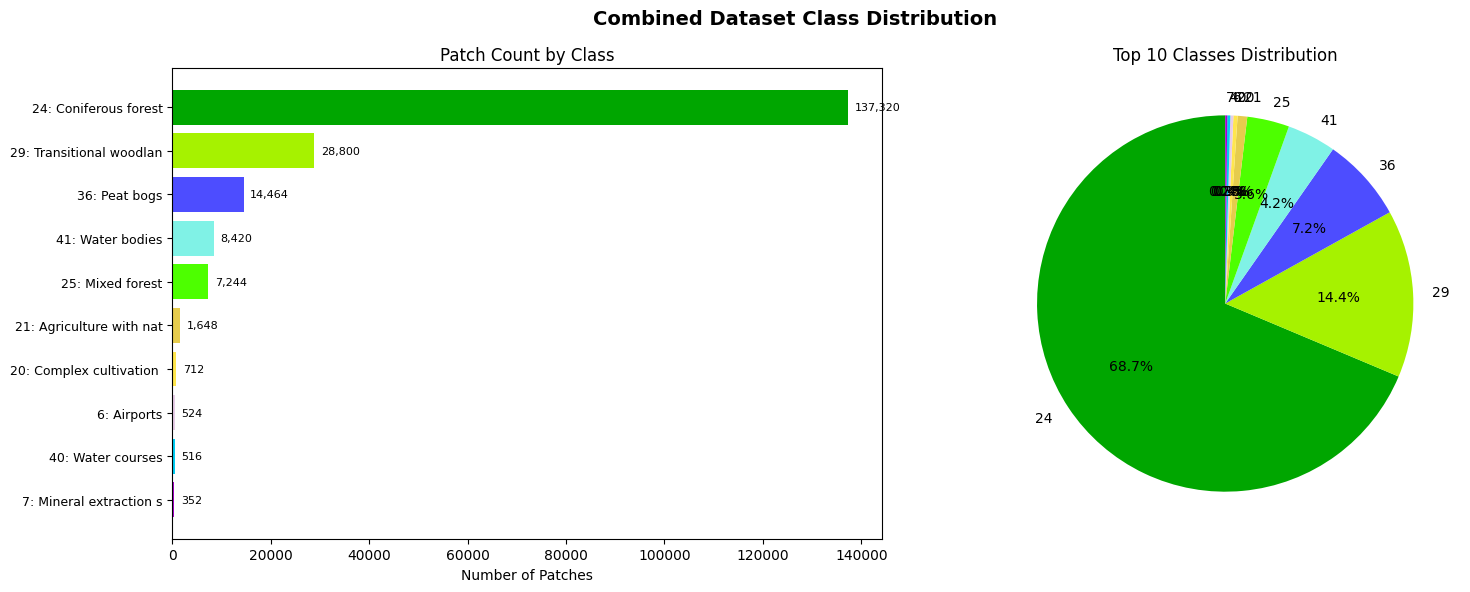


Statistics:
  Total patches: 200,000
  Unique classes: 10
  Most common: Class 24 (Coniferous forest) - 137,320 (68.7%)
  Least common: Class 7 (Mineral extraction sites) - 352 (0.2%)
  Class imbalance ratio: 390.1:1


In [13]:
def combine_datasets(result_list, output_path):
    """
    Combine patches from multiple tiles into a single dataset.
    """
    all_patches = []
    all_labels = []
    
    for result in result_list:
        if result['status'] not in ['success', 'skipped']:
            continue
        if not result['output_file'] or not Path(result['output_file']).exists():
            continue
        
        data = np.load(result['output_file'])
        patches = data['patches']
        labels = data['labels']
        
        all_patches.append(patches)
        all_labels.append(labels)
        
        print(f"  Added {len(labels):,} patches from {result['tile'][:40]}...")
    
    if not all_patches:
        print("No data to combine!")
        return None, None
    
    # Concatenate
    combined_patches = np.concatenate(all_patches, axis=0)
    combined_labels = np.concatenate(all_labels, axis=0)
    
    # Shuffle
    indices = np.random.permutation(len(combined_labels))
    combined_patches = combined_patches[indices]
    combined_labels = combined_labels[indices]
    
    # Save
    np.savez_compressed(output_path, patches=combined_patches, labels=combined_labels)
    
    print(f"\n✓ Combined dataset saved: {output_path}")
    print(f"  Total patches: {len(combined_labels):,}")
    print(f"  Unique classes: {len(np.unique(combined_labels))}")
    print(f"  File size: {Path(output_path).stat().st_size / (1024**2):.1f} MB")
    
    return combined_patches, combined_labels


# Combine all successful results
if len(successful_results) > 1:
    print("Combining datasets from multiple tiles...\n")
    combined_path = Path(OUTPUT_DIR) / "combined_training_data.npz"
    combined_patches, combined_labels = combine_datasets(all_results, combined_path)
    
    if combined_patches is not None:
        plot_class_distribution(combined_labels, title="Combined Dataset Class Distribution")
elif len(successful_results) == 1:
    print("Only one tile processed - no need to combine.")
    print(f"Your training data is at: {successful_results[0]['output_file']}")
else:
    print("No successful results to combine.")

## Summary & Next Steps

### What We Accomplished
✅ Loaded aligned S2 and CORINE data from Lab 4.1  
✅ Applied normalization to satellite imagery  
✅ Extracted fixed-size training patches with center-pixel labels  
✅ Analyzed class distributions  
✅ Saved ML-ready training datasets in `.npz` format  

### Output Files
- `patches_*_data.npz` - Training patches (normalized) and labels
- `patches_*_metadata.json` - Extraction parameters and statistics
- `combined_training_data.npz` - Combined dataset (if multiple tiles)

### Data Format
```python
data = np.load('patches_*_data.npz')
patches = data['patches']  # Shape: (N, H, W, 4) - float32, normalized
labels = data['labels']    # Shape: (N,) - uint8 (1-44)
```

### Key Takeaways
- Normalization helps ML models converge faster
- Percentile-based normalization is robust to outliers
- Center-pixel labeling assigns one class per patch
- Class imbalance is common - consider weighted loss in training

**Great work!** Your normalized training data is ready for deep learning! 🚀